## Astro kod

### Parser

In [1]:
# Parser
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits


from os import listdir
from os.path import isfile, join
import time
from datetime import datetime


# Returnerar lista av (band (int), tidpunkt (datetime), bild_data (np.ndarray av ra, dec, intensitet))
def parseFits(fits_dir):
    # Hämta lista av fits filer från mapp
    fits_files = [fits_file for fits_file in listdir(fits_dir) if isfile(join(fits_dir, fits_file))]

    observations = list()
    date_format = "%Y-%m-%dT%H:%M:%S.%f"

    # Gå igenom varje fits fil
    for fits_file in fits_files:
        # Öppna fitsfil
        # HDUList (Header Data Unit)
        hdul = fits.open(fits_dir + fits_file)
        # hdul.info() # Printar lite info om fitsfilen

        # Header information
        # Se: http://www.alma.inaf.it/images/ArchiveKeyworkds.pdf
        header = hdul[0].header
        #print(repr(header))

        # Få band
        band = int(fits_file[fits_file.find('B')+1])

        # Få observationsdatum och tid
        date_str = header['DATE-OBS']
        date = datetime.strptime(date_str, date_format)

        # Bilddatan
        intensities = np.squeeze(hdul[0].data)

        width, height = intensities.shape
        x_pixels = np.linspace(0, width, width)
        y_pixels = np.linspace(0, height, height)

        # Right ascension
        ra_ref = header['CRVAL1'] # RA referens i relation till Pixel referensen
        ra_delta = header['CDELT1'] # RA delta för varje pixel
        ra_pixel_ref = header['CRPIX1'] # Pixel positionen där RA referens gäller

        # Declination
        dec_ref = header['CRVAL2']
        dec_delta = header['CDELT2']
        dec_pixel_ref = header['CRPIX2']

        # Konvertera från pixel koordinater till ekvatoriella koordinater
        ras = ra_ref + (x_pixels - ra_pixel_ref) * ra_delta
        decs = dec_ref + (y_pixels - dec_pixel_ref) * dec_delta

        observations.append((band, date, ras, decs, intensities))

    return observations


In [2]:
# Parsea fits data för de tre AGB-stjärnorna
R_Dor = parseFits("data/RDor/")
R_Leo = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/")
W_Hya = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/")


### Centrum metoder

R Dorados Max intensitet 
R Dorados Gaussisk 
R Leonis Max intensitet 
R Leonis Gaussisk 
W Hydrae Max intensitet 
W Hydrae Gaussisk 
Star plot 


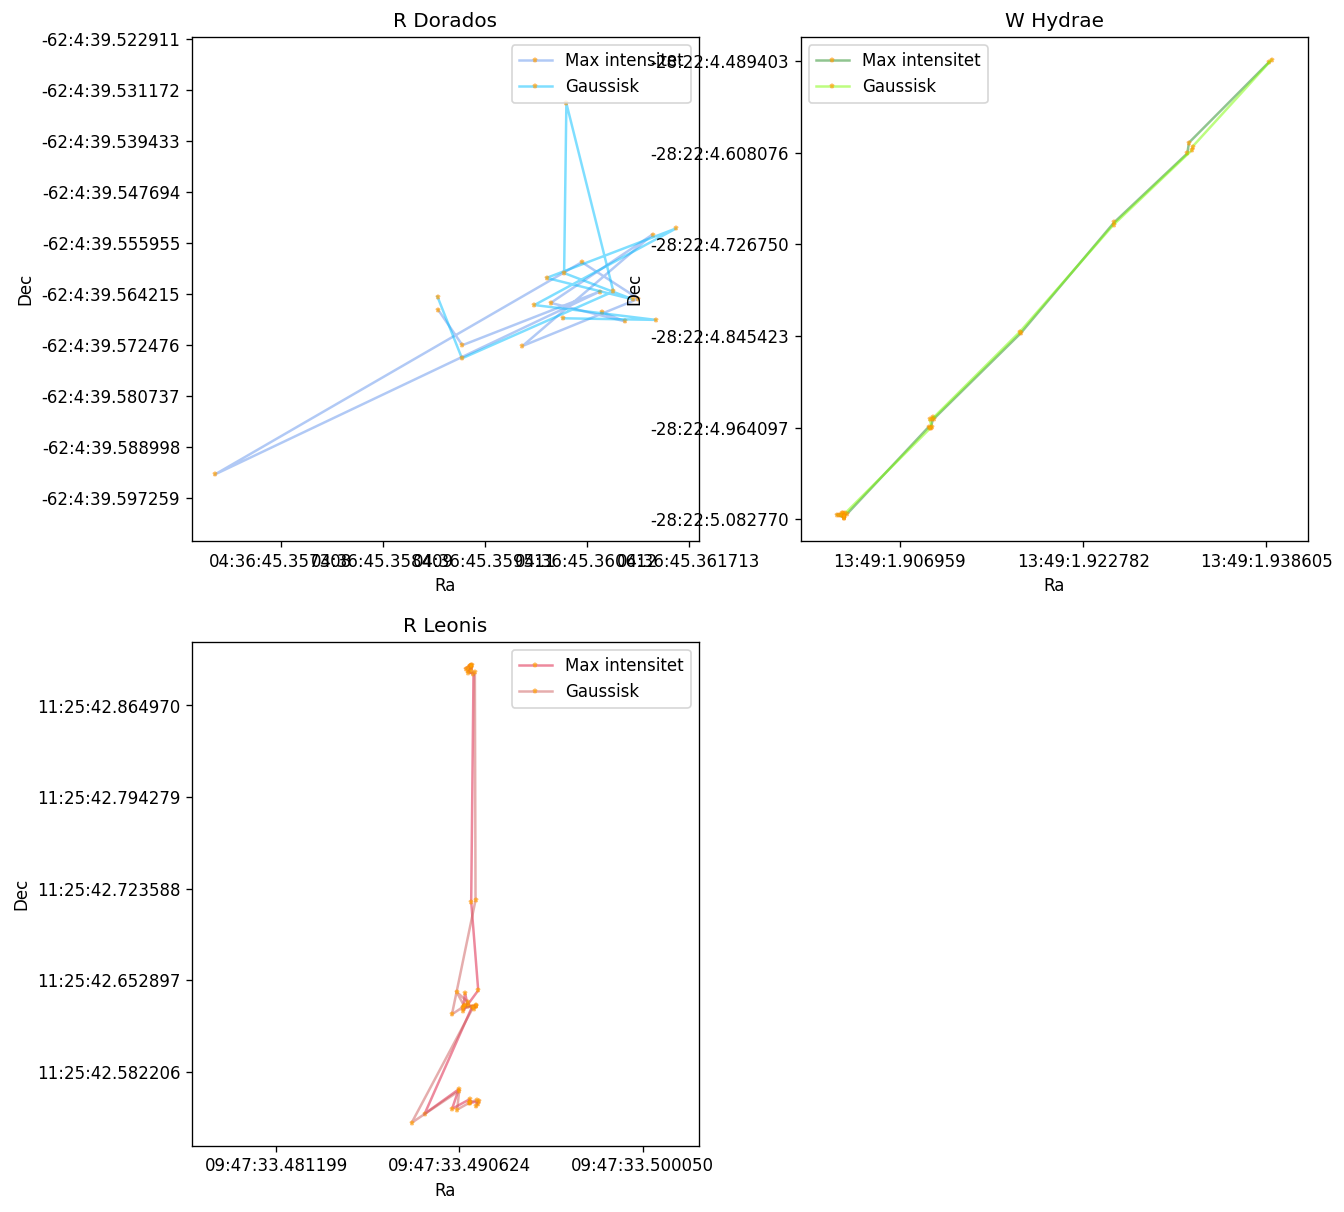

In [7]:
# Centrum metoder

import matplotlib.ticker as tick

from astropy.modeling import models, fitting

# Hitta centrum med ljusaste punkt:
def maxIntensitet(ras, decs, intensities, debug=False):
    # Hämta index för ljusaste intensitet
    j, i = np.unravel_index(np.argmax(intensities, axis=None), intensities.shape)

    return ras[i], decs[j], intensities[j, i]

# Få centerpunkter med metod och observationer
# Ger tillbaka tidpunkter, ra:s och dec:s
def getCenters(method, observations, debug=False):
    ts = []
    ras = []
    decs = []

    # Gå igenom varje observaton
    for observation in observations:
        ts.append(observation[1])
        if debug:
            print("Band: ", observation[0], "Tidpunkt: ", observation[1])
        ra, dec, intensitet = method(observation[2], observation[3], observation[4], debug=debug)

        ras.append(ra)
        decs.append(dec)

    # Sortera datan enligt observationstid
    idx = np.argsort(ts)

    ts = np.array(ts)[idx]
    ras = np.array(ras)[idx]
    decs = np.array(decs)[idx]
    data = np.array([ts, ras, decs])


    return data


# Formatterar deklinationen till string format
def decFormatter(dec, pos): 
    dec_deg = int(dec)
    dec_arcmin = int(60 * (dec - dec_deg))
    dec_arcsec = 60 * (60 * (dec - dec_deg) - dec_arcmin)

    #return f"{dec_deg}°{abs(dec_arcmin)}'{abs(dec_arcsec):.3f}''"
    return f"{dec_deg}:{abs(dec_arcmin)}:{abs(dec_arcsec):.6f}"

# Formatterar rektascension till string format
def raFormatter(ra, pos): 
    ra /= 15
    ra_hour = int(ra)
    ra_min = int(60 * (ra - ra_hour))
    ra_sec = 60 * (60 * (ra - ra_hour) - ra_min)

    #return f"{ra_hour}h{abs(ra_min)}m{abs(ra_sec):.3f}s"
    return f"{ra_hour:02d}:{abs(ra_min)}:{abs(ra_sec):.6f}"

# Hitta centrum med gauss anpassning:
def gaussIntensitet(ras, decs, intensities, debug=False):
    r, d = np.meshgrid(ras, decs)

    # Få ut maximala intensiteten som utgångspunkt för den gaussiansk anpassningen
    ra_max, dec_max, int_max = maxIntensitet(ras, decs, intensities)

    # Standard avvikelse satt till 12 arcsec, rimlig approximation av stjärnans radie
    stddev_factor = 12/(360*60*60)

    # Initala gauss modellen: Startpunkt för anpassningen
    gauss_init = models.Gaussian2D(amplitude=1, x_mean=ra_max, y_mean=dec_max, \
                                   x_stddev=stddev_factor, y_stddev=stddev_factor)
    
    # Anpassningsmetoden som fungerade bäst. TODO: Undersök varför och om det finns bättre anpassare
    gauss_fitter = fitting.DogBoxLSQFitter()

    # Gör gaussisk anpassning med en maximal iteration på 10'000, (lägre gav sämre resultat)
    gauss_model = gauss_fitter(gauss_init, r, d, intensities, maxiter=10000) 

    # För debug så plottas den initiala gauss modellen, den gaussiska anpassningen och ursprungliga stjärnbilden bredvid varandra.
    if debug:
        fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=120)
        fig.suptitle("")
        axs[0].set_title("Init")
        axs[0].pcolormesh(ras, decs, gauss_init(r, d))
        axs[0].plot(ra_max, dec_max, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        axs[1].set_title("Model")
        axs[1].pcolormesh(ras, decs, gauss_model(r, d))
        axs[1].plot(ra_max, dec_max, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        axs[2].set_title("Actual")
        axs[2].pcolormesh(ras, decs, intensities)
        axs[2].plot(ra_max, dec_max, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        plt.show()

    return gauss_model.x_mean.value, gauss_model.y_mean.value, gauss_model.amplitude.value



# Hitta centrum med halva max
def halvaMax(ras, decs, intensities, debug=False):
    #skaffa maxintensitet
    ra_max, dec_max, int_max= maxIntensitet(ras, decs, intensities, debug=False)
    halvint=[]
    halvras=[]
    halvdec=[]

    # Hitta data med ungefär halva maxintensiteten 
    for i in range(intensities.shape[0]):
        for j in range(intensities.shape[1]):

            # Går att testa olika intervall för att se vilket som fungerar bäst
            if intensities[i,j]>0.48*int_max and intensities[i,j]<0.52*int_max:
                halvint.append(intensities[i,j])
                halvras.append(ras[j])
                halvdec.append(decs[i])

    # Medelvärdera, kan testa andra sätt att interpolera ett centrum
    meanRas=np.mean(halvras)
    meanDec=np.mean(halvdec)
    meanint=np.mean(halvint)

    
    # Om man vill se figurer
    if debug:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=120)
        fig.suptitle("")
        axs[0].set_title("Medelvärde")
        axs[0].pcolormesh(ras, decs, intensities)
        axs[0].plot(meanRas, meanDec, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        axs[1].set_title("Halva max")
        axs[1].pcolormesh(ras, decs, intensities)
        axs[1].plot(halvras, halvdec, marker='*', markerfacecolor="gold", markeredgecolor="darkorange", alpha=0.5, markersize=3.0)
        plt.show()


    return meanRas, meanDec, meanint


# Plottar varje graf från centrum och formatterar axlar
def plotter(ax, centers, color, label):
    ax.plot(centers[1], centers[2], marker='*', color=color, markerfacecolor="gold", markeredgecolor="darkorange", label=label, markersize=3.0, alpha=0.5)
    ax.axis('equal') # 1 grad RA = 1 grad dec
    ax.set_xlabel("Ra")
    ax.set_ylabel("Dec")

    # Formattera ticks så att de har rimligt avstånd (för den långa texten) och rätt dec/ra format
    max_scale = max(np.max(centers[1]) - np.min(centers[1]), np.max(centers[2]) - np.min(centers[2]))
    ax.xaxis.set_major_locator(tick.MultipleLocator(base=0.4*max_scale))
    ax.yaxis.set_major_locator(tick.MultipleLocator(base=0.2*max_scale))
    ax.xaxis.set_major_formatter(tick.FuncFormatter(raFormatter))
    ax.yaxis.set_major_formatter(tick.FuncFormatter(decFormatter))

def toAstroDataFile(fname, header, data):
    formatted_data = []
    for data_point in data.T:
        date = data_point[0]
        start = datetime(date.year, 1, 1)
        delta = date - start
        frac_year = date.year + delta.days / (366 if (start.year % 4 == 0) else 365)
        ra = data_point[1]
        dec = data_point[2]
        ra_error = 0.00035 # Dummy value for now
        dec_error = 0.0025 # Dummy value for now
        formatted_data.append((f"{frac_year:.3f}", raFormatter(ra, 0), f"{ra_error:.5f}", decFormatter(dec, 0), f"{dec_error:.5f}"))

    np.savetxt(fname=fname, header="date  RA  RA_error  Dec Dec_error", comments=header + "\n\n# ", X=formatted_data, fmt='%s', delimiter="  ")

def plotMethods(method1, method1_str, method2, method2_str):

    # Beräkna centrum för de två metoderna för varje stjärna
    print("R Dorados", method1_str, "\n=============================")
    R_Dor_center1 = getCenters(method1, R_Dor)
    print("R Dorados", method2_str, "\n=============================")
    R_Dor_center2 = getCenters(method2, R_Dor)
    print("R Leonis", method1_str, "\n=============================")
    R_Leo_center1 = getCenters(method1, R_Leo)
    print("R Leonis", method2_str, "\n=============================")
    R_Leo_center2 = getCenters(method2, R_Leo)
    print("W Hydrae", method1_str, "\n=============================")
    W_Hya_center1 = getCenters(method1, W_Hya)
    print("W Hydrae", method2_str, "\n=============================")
    W_Hya_center2 = getCenters(method2, W_Hya)

    # Spara data:
    toAstroDataFile(fname = "R_Dor_1.astrom.dat", header=f"name = R Dorados - {method1_str}", data=R_Dor_center1)
    toAstroDataFile(fname = "R_Dor_2.astrom.dat", header=f"name = R Dorados - {method2_str}", data=R_Dor_center2)
    toAstroDataFile(fname = "R_Leo_1.astrom.dat", header=f"name = R Leonis - {method1_str}", data=R_Leo_center1)
    toAstroDataFile(fname = "R_Leo_2.astrom.dat", header=f"name = R Leonis - {method2_str}", data=R_Leo_center2)
    toAstroDataFile(fname = "W_Hya_1.astrom.dat", header=f"name = W Hydrae - {method1_str}", data=W_Hya_center1)
    toAstroDataFile(fname = "W_Hya_2.astrom.dat", header=f"name = W Hydrae - {method2_str}", data=W_Hya_center2)

    print("Star plot", "\n=============================")
    # Skapa figur för att plotta de olika fallen
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=120)

    # Plotta alla centrum
    axs[0,0].set_title("R Dorados")
    axs[1,0].set_title("R Leonis")
    axs[0,1].set_title("W Hydrae")

    plotter(axs[0,0], R_Dor_center1, "cornflowerblue", method1_str)
    plotter(axs[1,0], R_Leo_center1, "crimson", method1_str)
    plotter(axs[0,1], W_Hya_center1, "forestgreen", method1_str)

    plotter(axs[0,0], R_Dor_center2, "deepskyblue", method2_str)
    plotter(axs[1,0], R_Leo_center2, "indianred", method2_str)
    plotter(axs[0,1], W_Hya_center2, "lawngreen", method2_str)

    axs[0,0].legend()
    axs[1,0].legend()
    axs[0,1].legend()

    axs[1,1].set_axis_off()

    return R_Dor_center1, R_Dor_center2, R_Leo_center1, R_Leo_center2, W_Hya_center1, W_Hya_center2

# Beräkna centrum för max intensitet och gaussisk, plotta och jämför
R_Dor_MaxInt, R_Dor_Gauss, R_Leo_MaxInt, R_Leo_Gauss, W_Hya_MaxInt, W_Hya_Gauss = plotMethods(maxIntensitet, "Max intensitet", gaussIntensitet, "Gaussisk")

### Parallax (+Bootstrap)

In [11]:
import astropy.units as u
import jplephem # Need to install
from astropy.coordinates import solar_system_ephemeris

solar_system_ephemeris.set("jpl")

# Choose star to study
stars = {'R Doradus': [R_Dor_MaxInt, R_Dor_Gauss], 'W Hydrae': [W_Hya_MaxInt, W_Hya_Gauss], 'R Leonis': [R_Leo_MaxInt, R_Leo_Gauss]}

name = 'W Hydrae'
#name = 'R Doradus'
#name = 'R Leonis'

star = stars[name]
data = star[1] # 0 = MaxInt, 1 = Gauss


# Split the data
date = aspy.time.Time(data[0])
decs = np.deg2rad(np.asarray(data[2], dtype = float))
ras = np.deg2rad(np.asarray(data[1], dtype = float))


# ref_t is our reference epoch, right now its the mean date of all observations
ref_t = np.mean(date.decimalyear)
t = date.decimalyear - ref_t


# Use astropy to get earths barycentric coordinates at time t
def bary_coords(t):

    date = aspy.time.Time(t + ref_t, format = 'decimalyear')
    Epos = aspy.coordinates.get_body_barycentric('earth', date)

    X = Epos.x.to(u.au).value
    Y = Epos.y.to(u.au).value
    Z = Epos.z.to(u.au).value
    return X, Y, Z


# our model of the motion
def model(t, *params):

    ra0, dec0, parallax, pm_ra, pm_dec = params
    X, Y, Z = bary_coords(t)

    ra_model = ra0 + (pm_ra/np.cos(dec0))*t + (parallax/np.cos(dec0))*(X*np.sin(ra0) - Y*np.cos(ra0))
    dec_model = dec0 + pm_dec*t + parallax*(X*np.cos(ra0)*np.sin(dec0) + Y*np.sin(ra0)*np.sin(dec0) - Z*np.cos(dec0))

    return ra_model, dec_model

# Same as model, but without proper motion
def model_wopm(t, *params):

    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    X, Y, Z = bary_coords(t)

    ra_model = ra0 + (parallax/np.cos(dec0))*(X*np.sin(ra0) - Y*np.cos(ra0))
    dec_model = dec0 + parallax*(X*np.cos(ra0)*np.sin(dec0) + Y*np.sin(ra0)*np.sin(dec0) - Z*np.cos(dec0))

    return ra_model, dec_model

# Take observations, and remove its proper motion
def model_subtract_pm(t, ras, decs, *params):
    
    ra0, dec0, parallax, pm_ra, pm_dec = params
        
    ra_sub_pm = ras - ((pm_ra/np.cos(dec0)) * t)
    dec_sub_pm = decs - (pm_dec * t)
    print(f'ras before: {ras}, ras after {ra_sub_pm}')
    print(f'decs before: {decs}, decs after {dec_sub_pm}')
    return ra_sub_pm, dec_sub_pm


# residuals to use with least square fitting
def residuals(params, t, ras, decs):
    
    ra_model, dec_model = model(t, *params)

    residual_ra = (ras - ra_model) * np.cos(dec_model)
    residual_dec = decs - dec_model

    return np.concatenate([residual_ra, residual_dec])


### Analys

In [12]:
# take an initial guess of the parameters
masguess = 14 # initial parallax guess in mas
initial = [ras[0], decs[0], np.deg2rad(masguess/(3.6e6)), 0., 0.]
bounds = [(-np.inf, -np.inf, 0., -np.inf, -np.inf), (np.inf, np.inf, np.inf, np.inf, np.inf)]
# make the fit and get the results
result = sci.optimize.least_squares(residuals, initial, args = (t, ras, decs), max_nfev=5000, bounds = bounds)

params = np.rad2deg(result.x)*3.6e6 # convert fitted parameters to mas
ra0, dec0, parallax, pm_ra, pm_dec = params
ra0 = np.deg2rad(ra0/3.6e6)
dec0 = np.deg2rad(dec0/3.6e6)

# Estimate errors
jacobian = result.jac
resid = result.fun
m = len(resid)
n = len(result.x)
sigma2 = np.sum(resid**2) / (m - n)
cov = sigma2 * np.linalg.inv(jacobian.T @ jacobian)

params_std = np.rad2deg(np.sqrt(np.diag(cov)))*3.6e6

ra_cal, dec_cal = model(t, *result.x)


# print parallax
print(f'Params in rad: {result.x}, params in mas: {params}')
print(f'Standard deviation of all parameters in mas: {params_std}')
print(f'Parallax: {parallax:.3f} \u00B1 {params_std[2]:.3f} mas')


Params in rad: [ 3.61733398e+00 -4.95115567e-01  4.96316485e-08 -2.38833066e-07
 -2.96266517e-07], params in mas: [ 7.46128692e+08 -1.02124917e+08  1.02372624e+01 -4.92628562e+01
 -6.11093558e+01]
Standard deviation of all parameters in mas: [1.14286389 0.83602541 1.89062148 0.27492806 0.18476147]
Parallax: 10.237 ± 1.891 mas


c:\Users\bengu\AppData\Local\Programs\Python\Python312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 56 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Users\bengu\AppData\Local\Programs\Python\Python312\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "utctai" yielded 56 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


ras before: [3.61733589 3.61733539 3.61733539 3.61733489 3.61733431 3.61733375
 3.61733374 3.61733375 3.61733374 3.61733321 3.6173332  3.61733319
 3.6173332  3.61733318 3.6173332  3.6173332 ], ras after [3.61733398 3.617334   3.61733402 3.61733394 3.61733398 3.61733394
 3.61733393 3.61733397 3.61733397 3.61733392 3.61733391 3.61733391
 3.61733395 3.61733393 3.61733395 3.61733396]
decs before: [-0.49511349 -0.49511403 -0.49511406 -0.49511452 -0.4951152  -0.49511575
 -0.49511575 -0.4951158  -0.4951158  -0.49511633 -0.49511633 -0.49511634
 -0.49511635 -0.49511635 -0.49511636 -0.49511636], decs after [-0.49511557 -0.49511555 -0.49511555 -0.49511557 -0.49511556 -0.49511555
 -0.49511554 -0.49511556 -0.49511556 -0.49511556 -0.49511555 -0.49511555
 -0.49511554 -0.49511553 -0.49511555 -0.49511554]


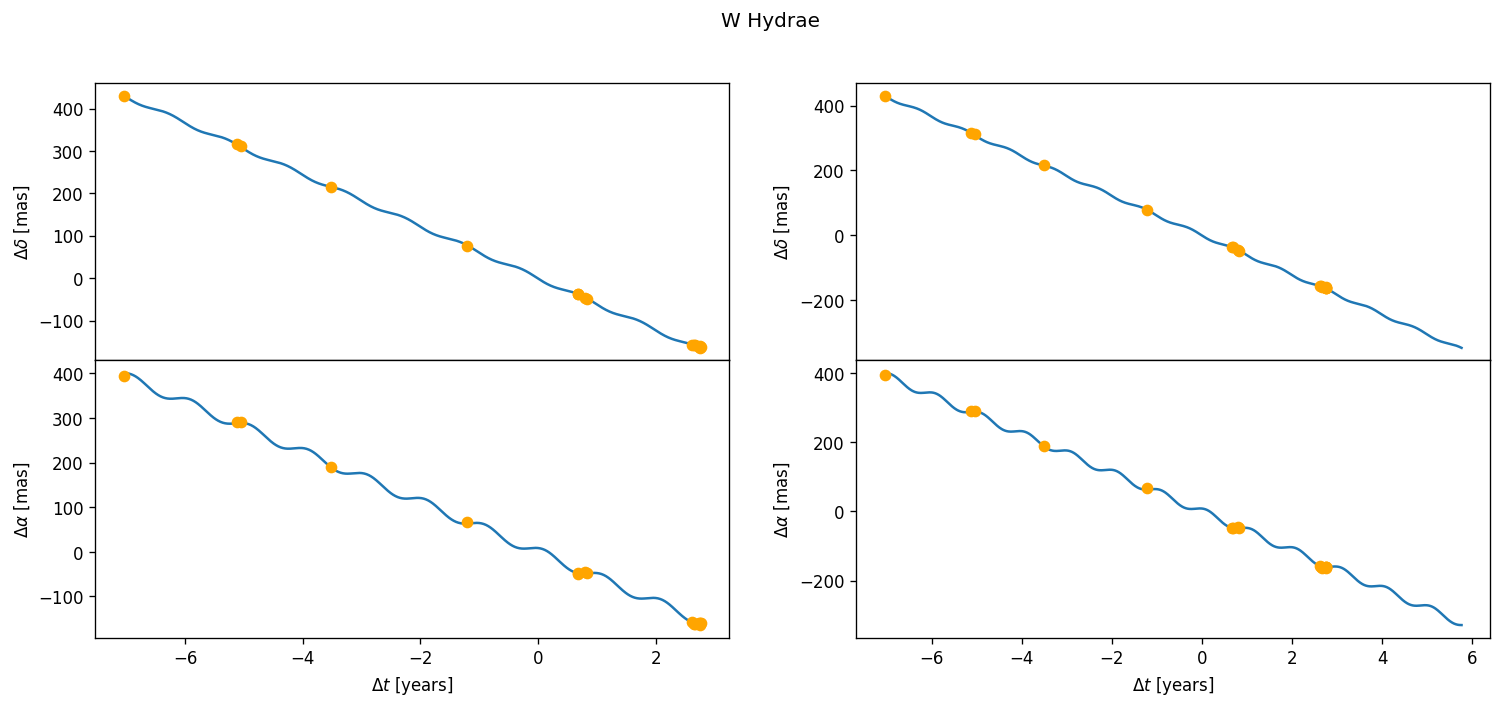

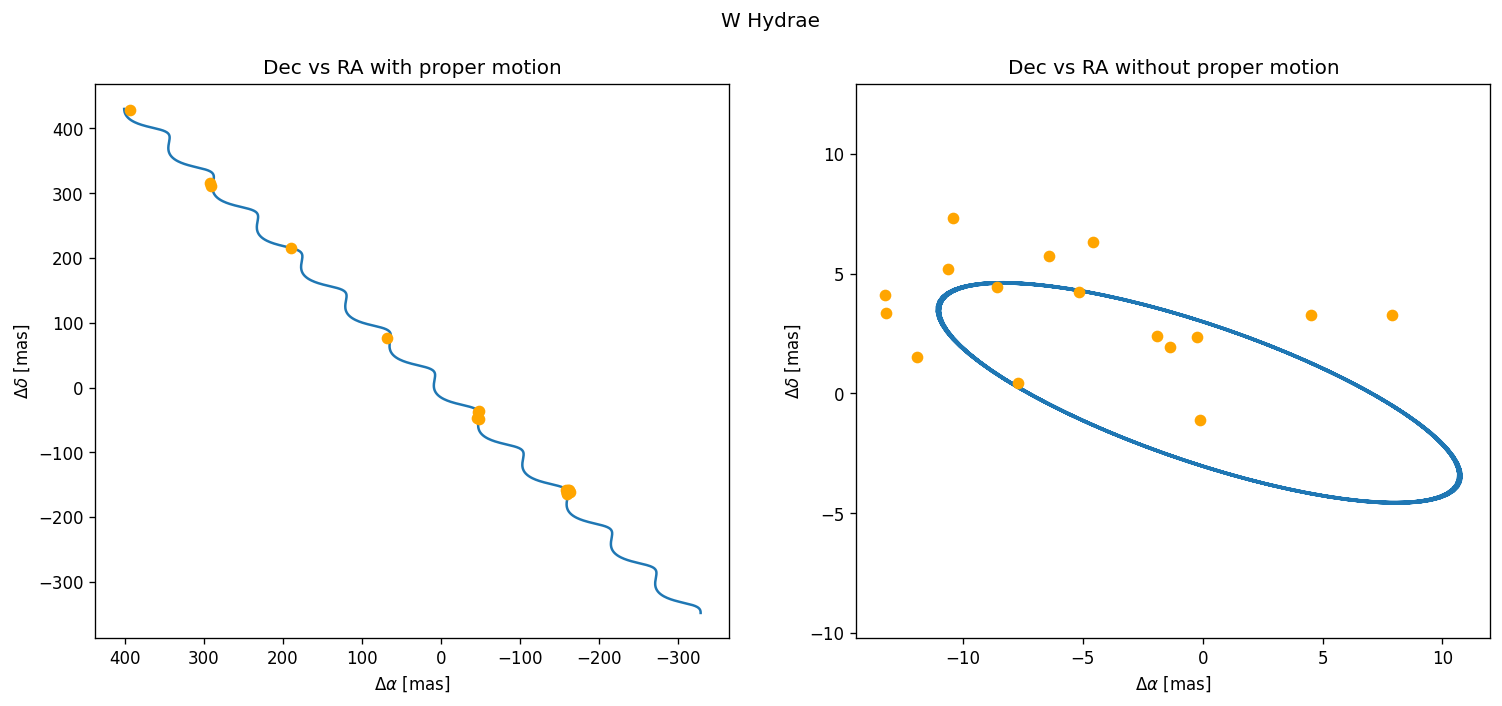

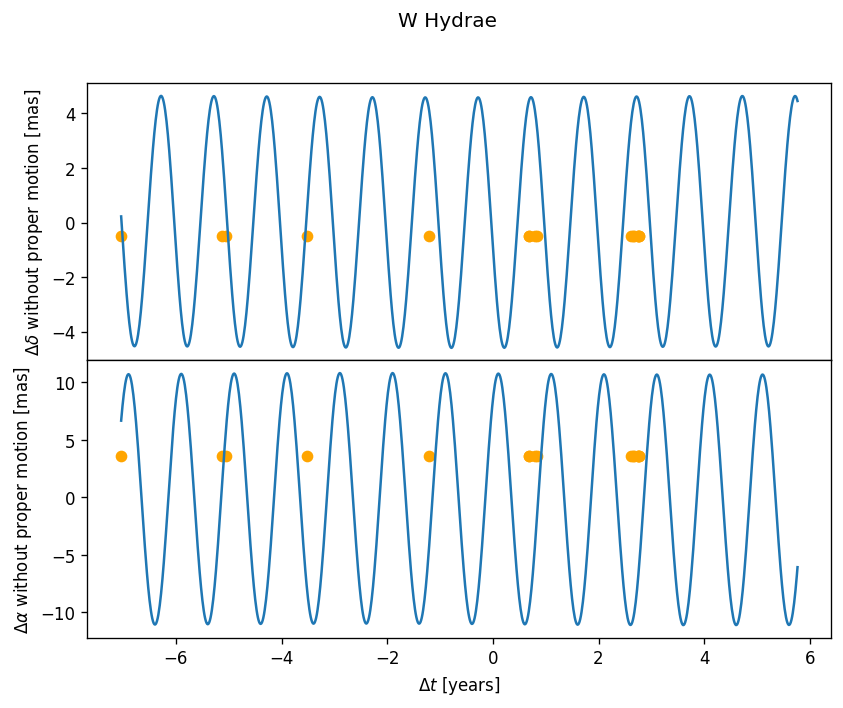

In [13]:
# plots
# make some hypothetical dates to use for plots
hypothetical = np.linspace(t[0], t[-1], 1000)
hypothetical_extended = np.linspace(t[0], t[-1]+3, 1000)
hypothetical_year = np.linspace(t[0], t[0]+1, 1000)

ra_mod, dec_mod = model(hypothetical, *result.x)
ra_mod_long, dec_mod_long = model(hypothetical_extended, *result.x)
ra_mod_wopm, dec_mod_wopm = model_wopm(hypothetical_extended, *result.x)
ra_wopm, dec_wopm = model_subtract_pm(t, ras, decs, *result.x)
# print(3.6e6*np.rad2deg(ra_mod))
#print(3.6e6*np.rad2deg(ras))



fig, ax = plt.subplots(2,2, figsize = (15,6), dpi = 120, sharex='col')
fig.subplots_adjust(hspace=0)  # increase vertical spacing
plt.suptitle(name)

ax[0][0].plot(hypothetical, 3.6e6*np.rad2deg(dec_mod-dec0), zorder = 0)
ax[0][0].scatter(t, 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
ax[0][0].set_ylabel(r'$\Delta\delta$ [mas]')


ax[1][0].plot(hypothetical, 3.6e6*np.rad2deg(ra_mod-ra0), zorder = 0)
ax[1][0].scatter(t, 3.6e6*np.rad2deg(ras-ra0), color = 'orange', zorder = 1)
ax[1][0].set_xlabel(r'$\Delta t$ [years]')
ax[1][0].set_ylabel(r'$\Delta\alpha$ [mas]')


ax[0][1].plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod_long-dec0), zorder = 0)
ax[0][1].scatter(t, 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
ax[0][1].set_ylabel(r'$\Delta\delta$ [mas]')


ax[1][1].plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod_long-ra0), zorder = 0)
ax[1][1].scatter(t, 3.6e6*np.rad2deg(ras-ra0), color = 'orange', zorder = 1)
ax[1][1].set_xlabel(r'$\Delta t$ [years]')
ax[1][1].set_ylabel(r'$\Delta\alpha$ [mas]')
plt.show()

fig, ax = plt.subplots(1,2,figsize = (15,6), dpi = 120, sharex=False)
plt.suptitle(name)

ax[0].plot(3.6e6*np.rad2deg(ra_mod_long-ra0), 3.6e6*np.rad2deg(dec_mod_long-dec0), zorder = 0)
ax[0].scatter(3.6e6*np.rad2deg(ras-ra0), 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
#ax[0].axis('equal') # 1 grad RA = 1 grad dec
ax[0].invert_xaxis()
ax[0].set_title(r'Dec vs RA with proper motion')
ax[0].set_xlabel(r'$\Delta\alpha$ [mas]')
ax[0].set_ylabel(r'$\Delta\delta$ [mas]')



ax[1].plot(3.6e6*np.rad2deg(ra_mod_wopm-ra0), 3.6e6*np.rad2deg(dec_mod_wopm-dec0), zorder = 0)
ax[1].scatter(3.6e6*np.rad2deg(ra_wopm-ra0), 3.6e6*np.rad2deg(dec_wopm-dec0), color = 'orange', zorder = 1)
ax[1].axis('equal') # 1 grad RA = 1 grad dec
ax[1].set_title(r'Dec vs RA without proper motion')
ax[1].set_xlabel(r'$\Delta\alpha$ [mas]')
ax[1].set_ylabel(r'$\Delta\delta$ [mas]')

plt.show()

fig, ax = plt.subplots(2,1, figsize = (8,6), dpi = 120, sharex=True)
fig.subplots_adjust(hspace=0)  # increase vertical spacing
plt.suptitle(name)

ax[0].plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
ax[0].scatter(t, dec_wopm, color = 'orange')
ax[0].set_ylabel(r'$\Delta\delta$ without proper motion [mas]')


ax[1].plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod_wopm-ra0))
ax[1].scatter(t, ra_wopm, color = 'orange')
ax[1].set_ylabel(r'$\Delta\alpha$ without proper motion [mas]')

ax[1].set_xlabel(r'$\Delta t$ [years]')

plt.show()